In [1]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../data/empirical_networks/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
# import dill
# import os
# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = dill.load(f)


In [6]:
# import pickle
# import os

# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = pickle.load(f)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:03<00:00, 3212.25it/s]


steps:  10000
conclusion:  0.09935897435897435
conclusion core 0.17647058823529413


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0.521897,0.184083,0.678277,0.362044,0.453778,0.793625,0.019562,0.489268,0.932871,0.648828,...,0.215588,0.007912,0.826812,0.664077,0.267793,0.363575,0.834281,0.962680,0.920763,0.726277
1,0.517904,0.185288,0.680020,0.362044,0.453778,0.790992,0.019562,0.487269,0.932368,0.656084,...,0.216944,0.007912,0.827954,0.660499,0.267793,0.363575,0.832057,0.962391,0.923066,0.724683
2,0.515906,0.185288,0.681758,0.362044,0.453778,0.786997,0.019562,0.473292,0.930322,0.661479,...,0.214238,0.007912,0.825663,0.658702,0.267793,0.363575,0.829809,0.962966,0.921923,0.729446


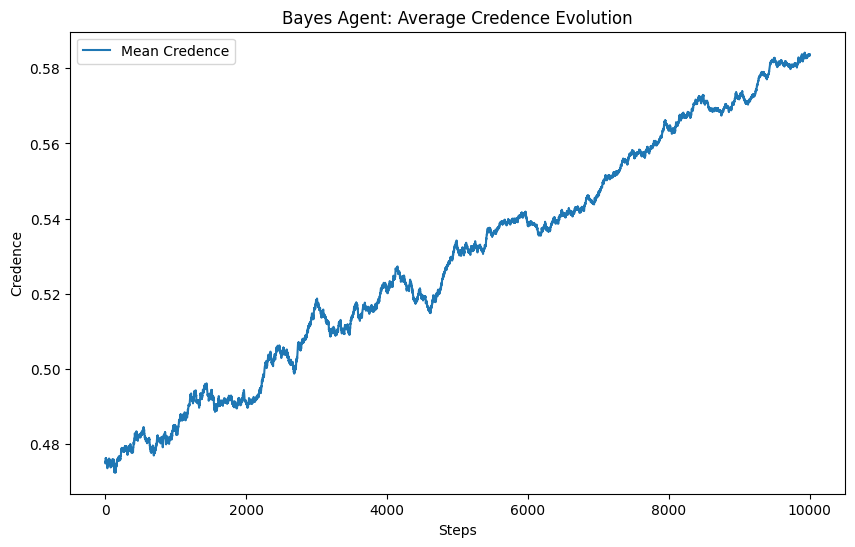

In [8]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [9]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:04<00:00, 2121.70it/s]


steps:  10000
conclusion:  0.6217948717948718


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,"[0.3137501891779255, 0.44575235062760904]","[1.3344050753236123e-05, 0.9999997893845024]","[0.040958986738300784, 0.8103406340228847]","[0.035903693884368246, 0.21369930406822102]","[0.37727254678649846, 0.3510390079269277]","[0.6604555234071577, 0.5491861669864185]","[0.9956731691539001, 0.8493526587550924]","[3.237237536253006e-53, 0.5703487858080588]","[0.13434173287077336, 0.07385128654674515]","[0.6464554622737966, 0.04878525879377202]",...,"[0.15231217281476664, 0.8293331952340941]","[0.7855821739703455, 0.7743446619585744]","[0.2841384662198304, 0.9999999999998551]","[0.3485928442233127, 0.14514404643868312]","[0.31322091118145684, 0.7025242872375842]","[0.9130596313588016, 0.3650662479523264]","[0.07390622583710943, 0.09528747356471978]","[0.030402696340882118, 0.04150057389564657]","[0.7574236835315954, 0.09469762703436478]","[0.591176213101694, 0.9277267755923269]"
1,"[0.10265289954505152, 0.517713872497061]","[0.4093881396822927, 0.6568283602794831]","[0.03537372657528005, 0.45507319142911695]","[0.6738659457896781, 0.31321572623283167]","[0.42284676528092996, 0.39679001193168856]","[0.7843746173553021, 0.5820080114499822]","[0.8071891949621254, 0.6057225713136538]","[0.307588040577636, 0.4108895143586023]","[0.7391266761929278, 0.358862269196978]","[0.44262370889237357, 0.3298341744223392]",...,"[0.3545616665106674, 0.4635807070344075]","[0.500122396946861, 0.1437312811459908]","[0.7027955533547456, 0.5044209201242975]","[0.6834665962581433, 0.5645713170277771]","[0.0003237297313301386, 0.8564463476648828]","[0.5404115049140341, 0.732156329547862]","[0.3786602100945354, 0.39507838594223305]","[0.5569008134213037, 0.41054215485535994]","[0.4025443546205798, 0.004159483728485075]","[0.6465063575378271, 0.4358952512632685]"
2,"[0.42740259402809, 0.3681474868007936]","[0.6630946534222935, 0.7648840640060579]","[0.12556924412307413, 0.3472973947148653]","[0.592431050767476, 0.18864533489073357]","[0.36220967998934284, 0.4339368115888944]","[0.6679176956483751, 0.5804483559992082]","[0.7023334535036989, 0.5225016386747997]","[0.5493667329141882, 0.527002629073271]","[0.6058030843089242, 0.17954465893494773]","[0.42090301386214085, 0.32617161776605796]",...,"[0.7239430160648249, 0.46946917963923573]","[0.483396474777332, 0.006079497927890515]","[0.5545114366181217, 0.5560504952816325]","[0.4963406894180919, 0.22435970605166436]","[0.05021142310540737, 0.9071373053289646]","[0.4949134721355169, 0.33559119650286934]","[0.5544678743053889, 0.6429671543120072]","[0.4769361246666032, 0.12799502792783873]","[0.5916358171287888, 0.02026589900751841]","[0.4559341694869642, 0.3529807194876177]"


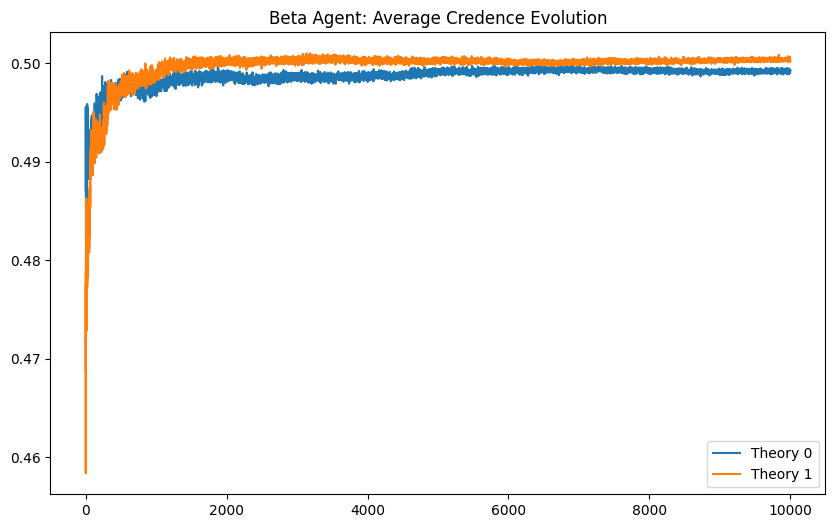

In [10]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

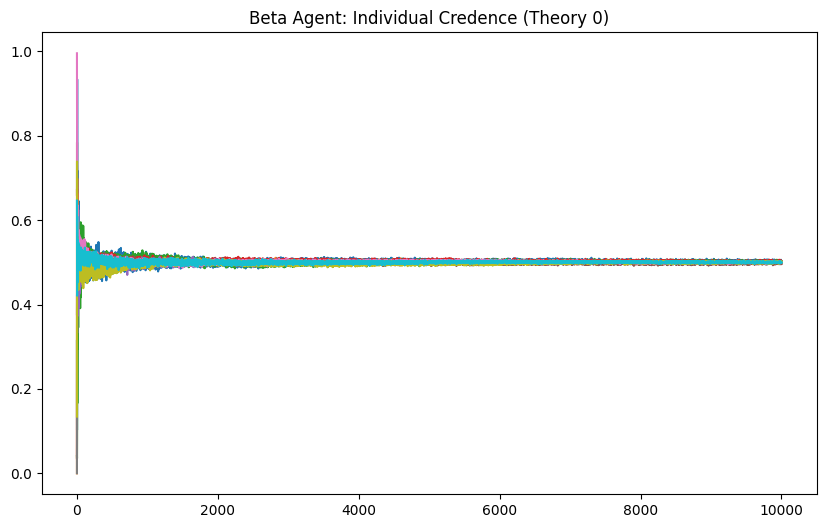

In [11]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()